In [2]:
#Imports
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

In [3]:
#fetch live aapl data
TICKER = "AAPL"

df = yf.download(TICKER, start="2010-01-01", auto_adjust=True)
df = df.reset_index()

# yfinance sometimes returns multi-level columns — flatten if needed
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [c[0] for c in df.columns]

print(df.shape)
print("Date range:", df['Date'].min(), "to", df['Date'].max())
df.head()

[*********************100%***********************]  1 of 1 completed

(4206, 6)
Date range: 2010-01-04 00:00:00 to 2026-09-23 00:00:00


,Date,Close,High,Low,Open,Volume
0,2010-01-04,6.400960,6.415616,6.352207,6.383612,493729600
1,2010-01-05,6.412027,6.448218,6.378229,6.418608,601904800
2,2010-01-06,6.310033,6.437448,6.303453,6.412025,552160000
3,2010-01-07,6.298369,6.340841,6.252607,6.333364,477131200
4,2010-01-08,6.340243,6.340842,6.252908,6.289995,447610800


In [4]:
# basic info & missing value check
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nLatest data:\n", df.tail())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4206 entries, 0 to 4205
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    4206 non-null   datetime64[ns]
 1   Close   4206 non-null   float64       
 2   High    4206 non-null   float64       
 3   Low     4206 non-null   float64       
 4   Open    4206 non-null   float64       
 5   Volume  4206 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 197.3 KB
None

Missing values:
 Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Latest data:
            Date       Close        High         Low        Open    Volume
4201 2026-09-17  337.000000  338.339996  330.179993  334.769989  36700200
4202 2026-09-18  336.130005  338.489990  332.529999  337.910004  86588200
4203 2026-09-21  338.980011  339.640015  333.049988  335.279999  34999200
4204 2026-09-22  339.750000  345.339996  338.750000 

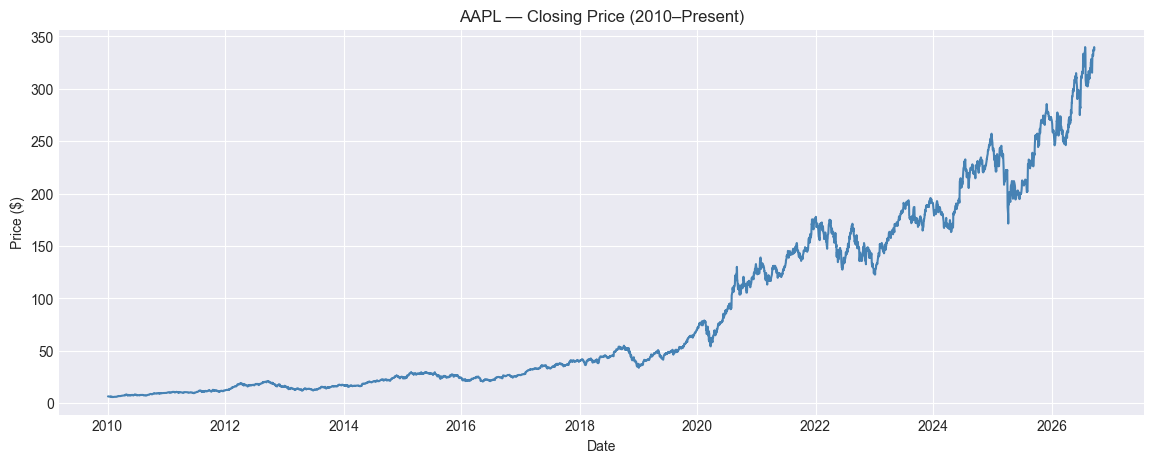

In [5]:
#price trend plot
plt.figure(figsize=(14,5))
plt.plot(df['Date'], df['Close'], color='steelblue')
plt.title(f'{TICKER} — Closing Price (2010–Present)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.show()

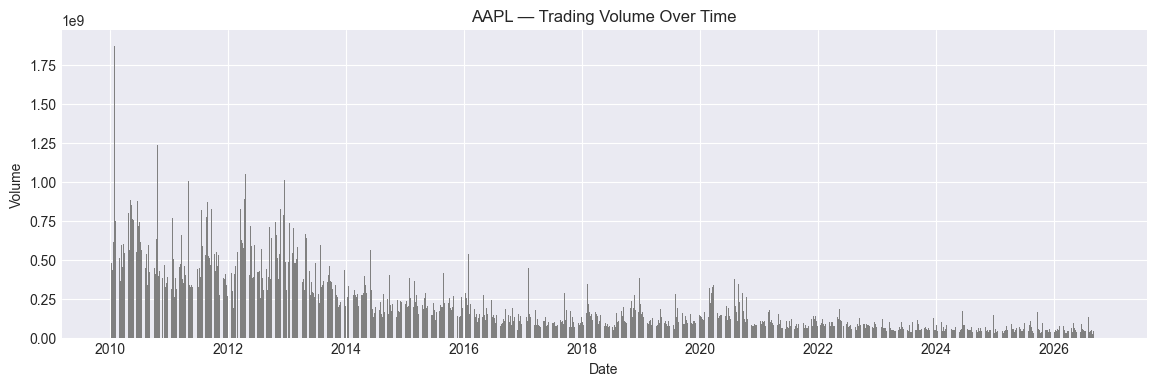

In [6]:
#volume trend
plt.figure(figsize=(14,4))
plt.bar(df['Date'], df['Volume'], color='gray', width=1)
plt.title(f'{TICKER} — Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

In [7]:
#key stats dashboard (numbers traders actually check)
current_price = df['Close'].iloc[-1]
fifty_two_wk = df[df['Date'] >= df['Date'].max() - pd.Timedelta(days=365)]

stats = {
    "Current Price": f"${current_price:.2f}",
    "52-Week High": f"${fifty_two_wk['Close'].max():.2f}",
    "52-Week Low": f"${fifty_two_wk['Close'].min():.2f}",
    "All-Time High": f"${df['Close'].max():.2f}",
    "All-Time Low": f"${df['Close'].min():.2f}",
    "Avg Daily Volume (1yr)": f"{fifty_two_wk['Volume'].mean():,.0f}",
}

for k, v in stats.items():
    print(f"{k:25}: {v}")

Current Price            : $337.02
52-Week High             : $339.79
52-Week Low              : $244.37
All-Time High            : $339.79
All-Time Low             : $5.74
Avg Daily Volume (1yr)   : 48,509,467


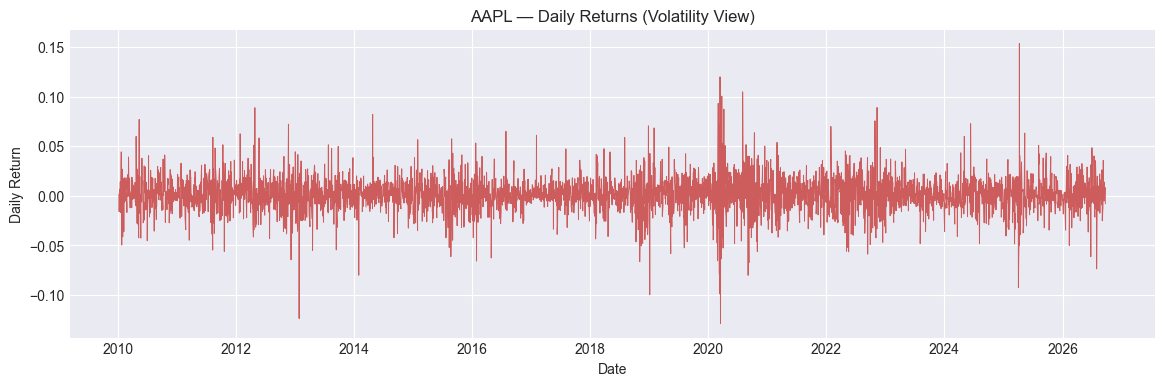

Annualized Volatility: 28.11%


In [8]:
# daily returns & volatility
df['Daily_Return'] = df['Close'].pct_change()

plt.figure(figsize=(14,4))
plt.plot(df['Date'], df['Daily_Return'], color='indianred', linewidth=0.7)
plt.title(f'{TICKER} — Daily Returns (Volatility View)')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.show()

print(f"Annualized Volatility: {df['Daily_Return'].std() * np.sqrt(252) * 100:.2f}%")

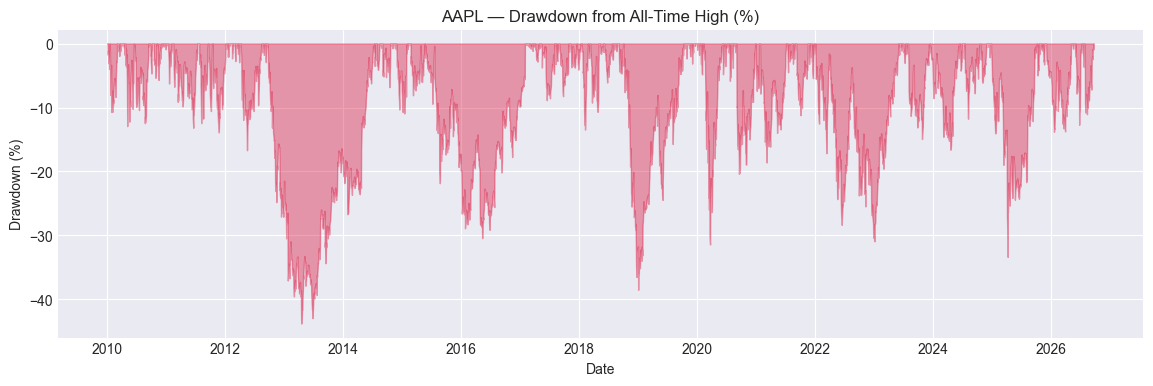

Max Drawdown Ever: -43.80%


In [9]:
#drawdown analysis (how much it ever fell from peak)
df['Cumulative_Max'] = df['Close'].cummax()
df['Drawdown'] = (df['Close'] - df['Cumulative_Max']) / df['Cumulative_Max']

plt.figure(figsize=(14,4))
plt.fill_between(df['Date'], df['Drawdown']*100, 0, color='crimson', alpha=0.4)
plt.title(f'{TICKER} — Drawdown from All-Time High (%)')
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.show()

print(f"Max Drawdown Ever: {df['Drawdown'].min()*100:.2f}%")

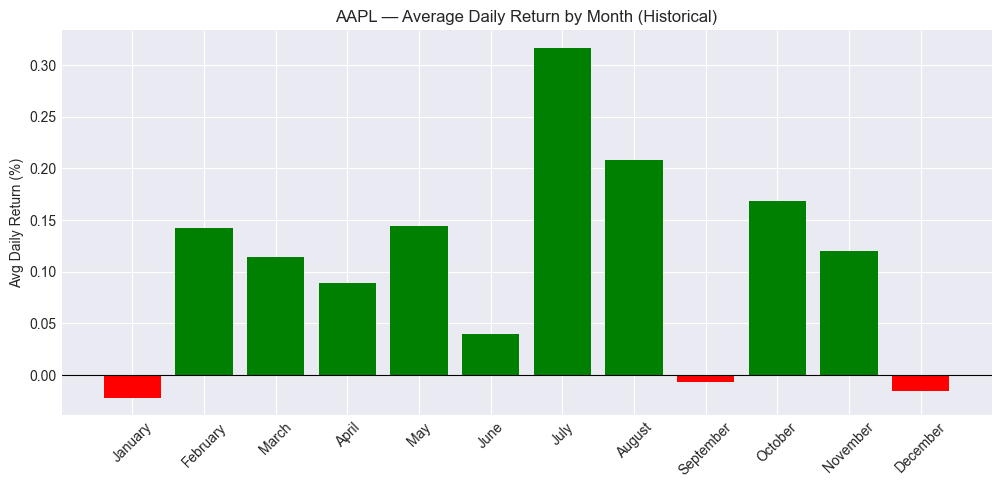

Month
July         0.316601
August       0.208448
October      0.168223
May          0.144164
February     0.142793
November     0.120052
March        0.114706
April        0.088764
June         0.039951
September   -0.006611
December    -0.015502
January     -0.021782
Name: Daily_Return, dtype: float64


In [10]:
#monthly seasonality (do certain months historically perform better?)
df['Month'] = df['Date'].dt.month_name()
monthly_returns = df.groupby('Month')['Daily_Return'].mean() * 100

month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
monthly_returns = monthly_returns.reindex(month_order)

plt.figure(figsize=(12,5))
colors = ['green' if x > 0 else 'red' for x in monthly_returns]
plt.bar(monthly_returns.index, monthly_returns.values, color=colors)
plt.title(f'{TICKER} — Average Daily Return by Month (Historical)')
plt.ylabel('Avg Daily Return (%)')
plt.xticks(rotation=45)
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

print(monthly_returns.sort_values(ascending=False))

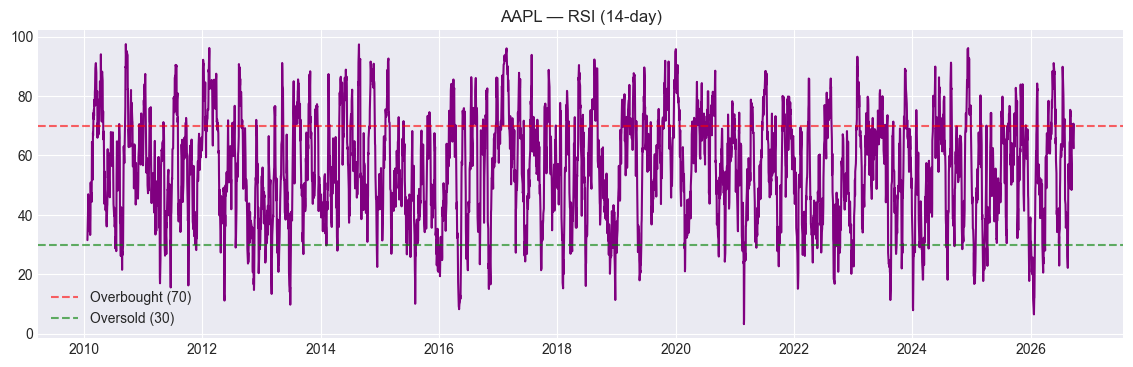

Current RSI: 62.44


In [11]:
#RSI (relative strength index)
def calculate_rsi(data, period=14):
    delta = data['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI'] = calculate_rsi(df)

plt.figure(figsize=(14,4))
plt.plot(df['Date'], df['RSI'], color='purple')
plt.axhline(70, color='red', linestyle='--', alpha=0.6, label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', alpha=0.6, label='Oversold (30)')
plt.title(f'{TICKER} — RSI (14-day)')
plt.legend()
plt.show()

print(f"Current RSI: {df['RSI'].iloc[-1]:.2f}")

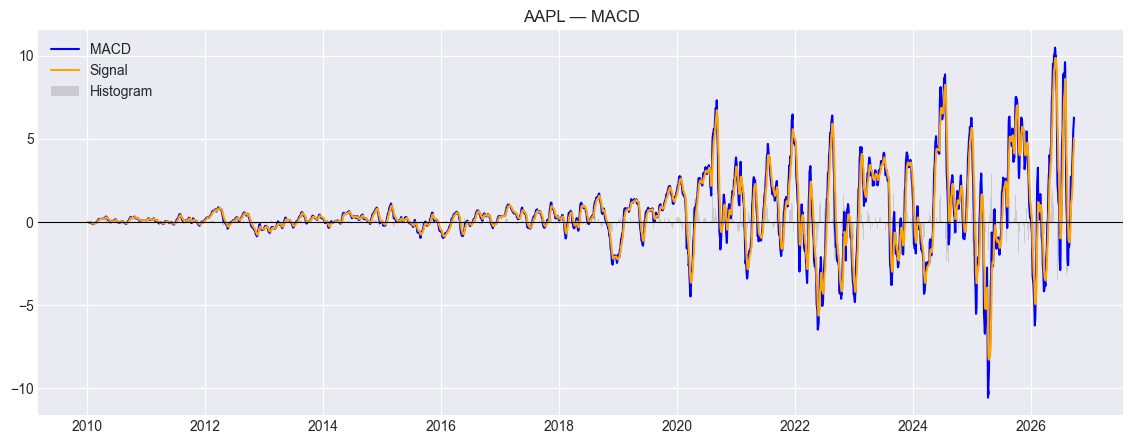

Current MACD: 6.23 | Signal: 5.03
Bullish crossover (MACD > Signal)


In [12]:
#MACD (moving average convergence divergence)
def calculate_macd(data, fast=12, slow=26, signal=9):
    ema_fast = data['Close'].ewm(span=fast, adjust=False).mean()
    ema_slow = data['Close'].ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram = macd_line - signal_line
    return macd_line, signal_line, histogram

df['MACD'], df['MACD_Signal'], df['MACD_Hist'] = calculate_macd(df)

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(df['Date'], df['MACD'], label='MACD', color='blue')
ax.plot(df['Date'], df['MACD_Signal'], label='Signal', color='orange')
ax.bar(df['Date'], df['MACD_Hist'], label='Histogram', color='gray', alpha=0.3, width=1)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title(f'{TICKER} — MACD')
ax.legend()
plt.show()

print(f"Current MACD: {df['MACD'].iloc[-1]:.2f} | Signal: {df['MACD_Signal'].iloc[-1]:.2f}")
print("Bullish crossover (MACD > Signal)" if df['MACD'].iloc[-1] > df['MACD_Signal'].iloc[-1] else "Bearish crossover (MACD < Signal)")

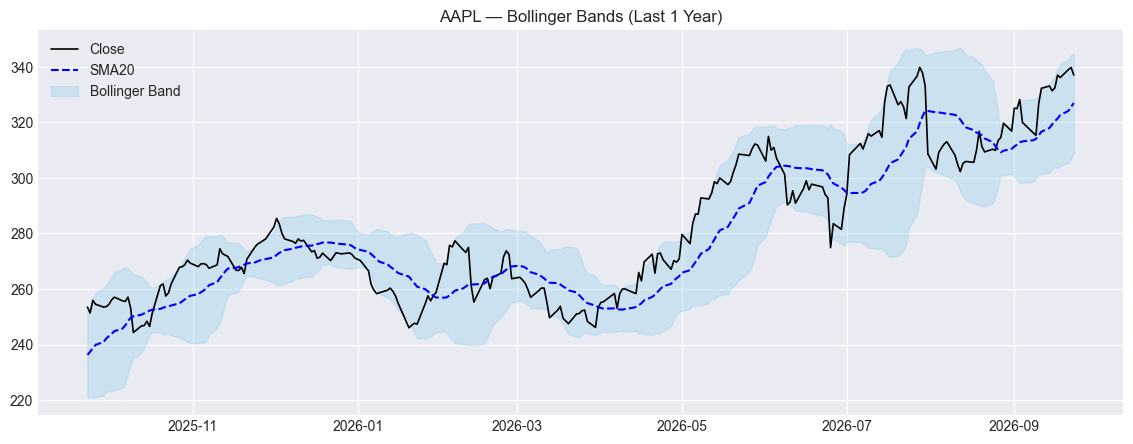

In [13]:
#Bollinger bands
def calculate_bollinger_bands(data, period=20, num_std=2):
    sma = data['Close'].rolling(period).mean()
    std = data['Close'].rolling(period).std()
    upper = sma + (std * num_std)
    lower = sma - (std * num_std)
    return sma, upper, lower

df['BB_Mid'], df['BB_Upper'], df['BB_Lower'] = calculate_bollinger_bands(df)

# Zoom into last 1 year for readability
recent = df[df['Date'] >= df['Date'].max() - pd.Timedelta(days=365)]

plt.figure(figsize=(14,5))
plt.plot(recent['Date'], recent['Close'], label='Close', color='black', linewidth=1.2)
plt.plot(recent['Date'], recent['BB_Mid'], label='SMA20', color='blue', linestyle='--')
plt.fill_between(recent['Date'], recent['BB_Upper'], recent['BB_Lower'], color='skyblue', alpha=0.3, label='Bollinger Band')
plt.title(f'{TICKER} — Bollinger Bands (Last 1 Year)')
plt.legend()
plt.show()

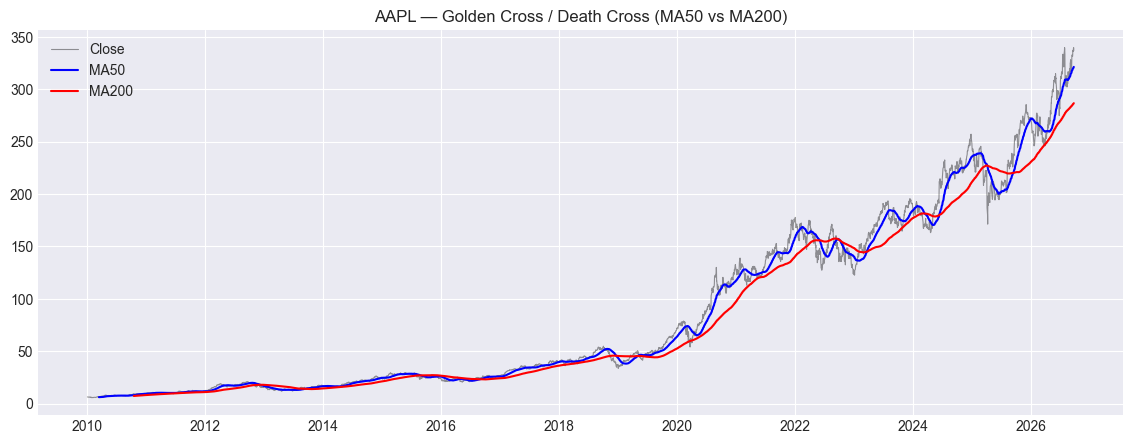

Current signal: Golden Cross (Bullish)


In [14]:
#moving average crossover (golden cross/ death cross)
df['MA50'] = df['Close'].rolling(50).mean()
df['MA200'] = df['Close'].rolling(200).mean()

plt.figure(figsize=(14,5))
plt.plot(df['Date'], df['Close'], label='Close', color='black', alpha=0.4, linewidth=0.8)
plt.plot(df['Date'], df['MA50'], label='MA50', color='blue')
plt.plot(df['Date'], df['MA200'], label='MA200', color='red')
plt.title(f'{TICKER} — Golden Cross / Death Cross (MA50 vs MA200)')
plt.legend()
plt.show()

current_signal = "Golden Cross (Bullish)" if df['MA50'].iloc[-1] > df['MA200'].iloc[-1] else "Death Cross (Bearish)"
print(f"Current signal: {current_signal}")

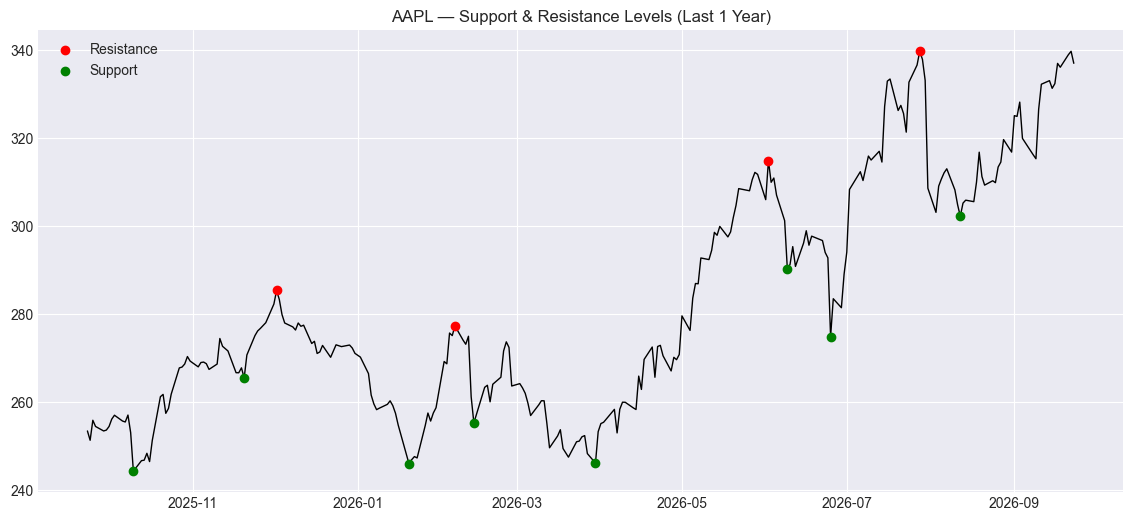

Recent resistance levels: [277.36505127 314.92840576 339.78692627]
Recent support levels: [290.29962158 274.91290283 302.25      ]


In [15]:
#support & resistance detection (recent swing highs/lows)
def find_support_resistance(data, window=20):
    data = data.copy()
    data['Local_Max'] = data['Close'][(data['Close'] == data['Close'].rolling(window, center=True).max())]
    data['Local_Min'] = data['Close'][(data['Close'] == data['Close'].rolling(window, center=True).min())]
    return data

df_sr = find_support_resistance(df)
recent_sr = df_sr[df_sr['Date'] >= df_sr['Date'].max() - pd.Timedelta(days=365)]

plt.figure(figsize=(14,6))
plt.plot(recent_sr['Date'], recent_sr['Close'], color='black', linewidth=1)
plt.scatter(recent_sr['Date'], recent_sr['Local_Max'], color='red', label='Resistance', zorder=5)
plt.scatter(recent_sr['Date'], recent_sr['Local_Min'], color='green', label='Support', zorder=5)
plt.title(f'{TICKER} — Support & Resistance Levels (Last 1 Year)')
plt.legend()
plt.show()

recent_resistance = recent_sr['Local_Max'].dropna().tail(3).values
recent_support = recent_sr['Local_Min'].dropna().tail(3).values
print("Recent resistance levels:", recent_resistance)
print("Recent support levels:", recent_support)

In [16]:
#Combined signals summary
latest = df.iloc[-1]

print("=== Current Technical Snapshot ===")
print(f"Price: ${latest['Close']:.2f}")
print(f"RSI: {latest['RSI']:.2f} -> {'Overbought' if latest['RSI']>70 else 'Oversold' if latest['RSI']<30 else 'Neutral'}")
print(f"MACD Signal: {'Bullish' if latest['MACD']>latest['MACD_Signal'] else 'Bearish'}")
print(f"MA Trend: {'Golden Cross (Bullish)' if latest['MA50']>latest['MA200'] else 'Death Cross (Bearish)'}")
print(f"Bollinger Position: {'Near Upper Band (overbought zone)' if latest['Close']>latest['BB_Upper']*0.98 else 'Near Lower Band (oversold zone)' if latest['Close']<latest['BB_Lower']*1.02 else 'Middle range'}")

=== Current Technical Snapshot ===
Price: $337.02
RSI: 62.44 -> Neutral
MACD Signal: Bullish
MA Trend: Golden Cross (Bullish)
Bollinger Position: Middle range


# 📊 EDA Report: Apple Inc. (AAPL) Stock Analysis
**A Technical & Statistical Deep-Dive into 16 Years of Market Data**

---

## 1. Project Overview

This analysis examines Apple Inc. (AAPL) stock performance from January 2010 to September 2026, 
using daily price and volume data. The goal is to understand the stock's historical behavior — 
its growth pattern, risk profile, cyclical tendencies, and current technical positioning — before 
building any predictive models. This EDA forms the foundation for a larger trend-analysis and 
trading-support system.

**Why this matters:** Before trusting any prediction model, it's essential to understand the raw 
behavior of the asset itself — how volatile it is, how it has recovered from past crashes, and 
whether there are recurring seasonal patterns. This report answers those questions with data.

---

## 2. Dataset Summary

| Detail | Value |
|---|---|
| Source | Live market data (Yahoo Finance, via yfinance) |
| Ticker | AAPL (Apple Inc.) |
| Date Range | Jan 1, 2010 – Sep 23, 2026 |
| Total Trading Days | 4,206 |
| Columns Used | Open, High, Low, Close, Volume, Date |
| Missing Values | None — dataset is complete and clean |

---

## 3. Price Growth Analysis

Over the ~16-year period studied, AAPL's closing price grew from approximately **$8 (2010)** to 
**$337 (2026)** — an increase of roughly **42x**. This reflects Apple's transformation from a 
strong tech company into one of the most valuable publicly traded companies in the world.

**Key observation:** Growth was not linear or smooth. The stock experienced several multi-month 
corrections and recoveries along the way — visible clearly in the price chart — meaning long-term 
gains came with real, sometimes painful, short-term volatility.

---

## 4. Volatility & Risk Profile

| Metric | Value | What it means |
|---|---|---|
| Annualized Volatility | 28.11% | On average, AAPL's price fluctuates ~28% per year — moderately high, typical for large tech stocks |
| Maximum Drawdown | ~ -44% | At its worst historical point, AAPL fell 44% from its previous all-time high before recovering |

**In plain terms:** Someone who invested at AAPL's peak before a downturn would have seen their 
investment temporarily lose nearly half its value before the stock recovered. This is important 
context — the long-term uptrend hides real short-term risk.

---

## 5. Trading Volume Trends

Trading volume (number of shares exchanged per day) has **declined structurally over time** — 
heaviest around 2010–2013, and notably lower in recent years. This is a normal pattern: as a 
stock's price rises significantly, fewer shares are needed to trade the same dollar value, so raw 
share volume naturally decreases even if investor interest hasn't.

---

## 6. Seasonality — Do Certain Months Perform Better?

Average daily returns were grouped by calendar month across the full history to check for 
recurring seasonal patterns:

**Historically Strongest Months** (highest average daily return):
1. July  
2. August  
3. October  

**Historically Weakest Months** (lowest average daily return):
1. January  
2. December  
3. September  

**Important caveat:** These are historical tendencies only, based on averages across many years — 
not a guarantee of future performance. Markets can and do behave differently from their historical 
seasonal patterns in any given year.

---

## 7. Technical Indicators — Explained Simply

Technical indicators are tools traders use to read a stock's recent momentum and behavior. 
Four widely-used indicators were calculated:

**RSI (Relative Strength Index)** — measures whether a stock has been bought or sold too 
aggressively recently, on a scale of 0–100. Above 70 = "overbought" (may be due for a pullback), 
below 30 = "oversold" (may be due for a bounce).
> Current RSI: **62.44** → Neutral zone, no extreme condition.

**MACD (Moving Average Convergence Divergence)** — measures momentum by comparing short-term and 
long-term price trends. When the MACD line crosses above its signal line, it's typically read as 
a bullish (upward momentum) signal.
> Current status: **Bullish** (MACD above signal line)

**Bollinger Bands** — a band around the price showing its normal trading range based on recent 
volatility. Price near the upper band suggests it's trading high relative to recent history; 
near the lower band suggests it's trading low.
> Current position: **Middle range** — not stretched in either direction

**Moving Average Crossover (Golden Cross / Death Cross)** — compares a 50-day average price to a 
200-day average price. When the shorter average is above the longer one ("Golden Cross"), it's a 
classic long-term bullish signal used by professional traders.
> Current status: **Golden Cross — Bullish**

**Support & Resistance Levels** — price points where the stock has historically struggled to rise 
above (resistance) or fall below (support), based on recent 1-year price action.
> Recent Resistance: ~$339.79   |   Recent Support: ~$302.25

---

## 8. Current Market Snapshot (as of Sep 23, 2026)

| Indicator | Reading | Interpretation |
|---|---|---|
| Price | $337.02 | — |
| RSI | 62.44 | Neutral |
| MACD | Bullish crossover | Positive momentum |
| MA50 vs MA200 | Golden Cross | Long-term bullish trend |
| Bollinger Position | Middle range | Not overextended |

**Overall Technical Read:** Mildly bullish, with no signs of extreme overbought conditions. 
Multiple independent indicators are currently aligned in a positive direction, though this reflects 
current technical positioning only — not a prediction of future price movement.

---

## 9. Key Takeaways

- AAPL has shown strong long-term growth (~42x over 16 years) but with real, sometimes sharp, 
  periods of decline (up to -44% drawdown) — long-term reward came with genuine short-term risk.
- Volatility (~28% annualized) is moderate-to-high, consistent with a large, actively-traded 
  tech stock.
- Seasonal patterns exist historically (stronger mid-to-late year, weaker in Jan/Dec/Sep) but 
  should be treated as a soft historical tendency, not a rule.
- All four major technical indicators are currently aligned in bullish territory, though none of 
  these tools predict the future with certainty — they describe current momentum and positioning.

---

## 10. Next Steps

This EDA lays the statistical and technical foundation for the next phase of the project: 
building and rigorously validating a trend-signal model (Stage 3 onward), along with deeper 
risk analytics — all designed to support, not replace, informed trading decisions.